# Big data? 🤗 Datasets to the rescue!

Nowadays it is not uncommon to find yourself working with multi-gigabyte datasets, especially if you’re planning to pretrain a transformer like BERT or GPT-2 from scratch. In these cases, even *loading* the data can be a challenge. For example, the WebText corpus used to pretrain GPT-2 consists of over 8 million documents and 40 GB of text — loading this into your laptop’s RAM is likely to give it a heart attack!

Fortunately, 🤗 Datasets has been designed to overcome these limitations. It frees you from memory management problems by treating datasets as *memory-mapped* files, and from hard drive limits by streaming the entries in a corpus.

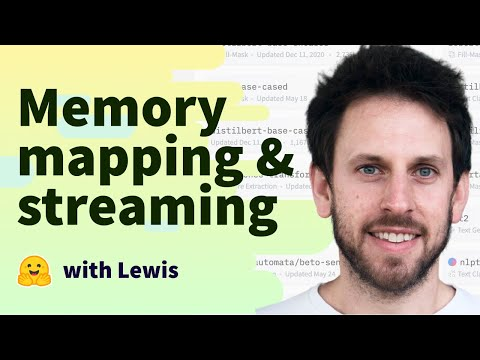

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("JwISwTCPPWo", width=800, height=450)

In this section we’ll explore these features of 🤗 Datasets with a huge 825 GB corpus known as [the Pile](https://pile.eleuther.ai/). Let’s get started!

In [2]:
!uv pip install -qq zstandard

## What is the Pile?

The Pile is an English text corpus that was created by [EleutherAI](https://www.eleuther.ai/) for training large-scale language models. It includes a diverse range of datasets, spanning scientific articles, GitHub code repositories, and filtered web text. The training corpus is available in [14 GB chunks](https://the-eye.eu/public/AI/pile/), and you can also download several of the [individual components](https://the-eye.eu/public/AI/pile_preliminary_components/). Let’s start by taking a look at the PubMed Abstracts dataset, which is a corpus of abstracts from 15 million biomedical publications on [PubMed](https://pubmed.ncbi.nlm.nih.gov/).

> Since original **The Pile** dataset is not available at the provided website, so, manually uploaded version is being used instead.

In [3]:
import aiohttp

In [4]:
from datasets import load_dataset

baseurl = "https://000010000000100100000000.blob.core.windows.net"
dataset = load_dataset(
    "json", 
    data_files=f"{baseurl}/datasets/PUBMED_title_abstracts_2019_baseline.jsonl.zst",
    split="train",
    storage_options={
        'client_kwargs': {
            'timeout': aiohttp.ClientTimeout(total=3600)
        }
    }
)
dataset

Loading dataset shards:   0%|          | 0/42 [00:00<?, ?it/s]

Dataset({
    features: ['meta', 'text'],
    num_rows: 15518009
})

---

We can see that there are 15,518,009 rows and 2 columns in our dataset — that’s a lot!

> ✎ By default, 🤗 Datasets will decompress the files needed to load a dataset. If you want to preserve hard drive space, you can pass `DownloadConfig(delete_extracted=True)` to the `download_config` argument of `load_dataset()`. See the documentation for more details.

Let’s inspect the contents of the first example:

In [5]:
dataset[0]

{'meta': {'pmid': 11409574, 'language': 'eng'},
 'text': 'Epidemiology of hypoxaemia in children with acute lower respiratory infection.\nTo determine the prevalence of hypoxaemia in children aged under 5 years suffering acute lower respiratory infections (ALRI), the risk factors for hypoxaemia in children under 5 years of age with ALRI, and the association of hypoxaemia with an increased risk of dying in children of the same age. Systematic review of the published literature. Out-patient clinics, emergency departments and hospitalisation wards in 23 health centres from 10 countries. Cohort studies reporting the frequency of hypoxaemia in children under 5 years of age with ALRI, and the association between hypoxaemia and the risk of dying. Prevalence of hypoxaemia measured in children with ARI and relative risks for the association between the severity of illness and the frequency of hypoxaemia, and between hypoxaemia and the risk of dying. Seventeen published studies were found that i

---

Okay, this looks like the abstract from a medical article. Now let’s see how much RAM we’ve used to load the dataset!

## The magic of memory mapping

A simple way to measure memory usage in Python is with the `psutil` library, which can be installed with pip as follows:

In [6]:
!uv pip install -qq psutil

It provides a `Process` class that allows us to check the memory usage of the current process as follows:

In [7]:
import psutil

# Process.memory_info provides information in bytes:
mem_usage = psutil.Process().memory_info().rss

print(f"RAM used: {mem_usage / (1024 * 1024):.2f} MB")

RAM used: 2663.36 MB


---

Here the `rss` attribute refers to the resident set size, which is the fraction of memory that a process occupies in RAM. This measurement also includes the memory used by the Python interpreter and the libraries we’ve loaded, so the actual amount of memory used to load the dataset is a bit smaller. For comparison, let’s see how large the dataset is on disk, using the `dataset_size` attribute. Since the result is expressed in bytes like before, we need to manually convert it to gigabytes:

In [8]:
dataset_size = dataset.dataset_size

# calculate size in GB:
size_in_gb = dataset.dataset_size / (1024 * 1024 * 1024)

print(f"Dataset (cached) size: {size_in_gb:.2f} GB")

Dataset (cached) size: 19.54 GB


---

Nice — despite it being almost 20 GB large, we’re able to load and access the dataset with much less RAM!

> ✏️ **Try it out!** Pick one of the [subsets](https://the-eye.eu/public/AI/pile_preliminary_components/) from the Pile that is larger than your laptop or desktop’s RAM, load it with 🤗 Datasets, and measure the amount of RAM used. Note that to get an accurate measurement, you’ll want to do this in a new process. You can find the decompressed sizes of each subset in Table 1 of the [Pile paper](https://arxiv.org/abs/2101.00027).

If you’re familiar with Pandas, this result might come as a surprise because of Wes Kinney’s famous [rule of thumb](https://wesmckinney.com/blog/apache-arrow-pandas-internals/) that you typically need 5 to 10 times as much RAM as the size of your dataset. So how does 🤗 Datasets solve this memory management problem? 🤗 Datasets treats each dataset as a [memory-mapped file](https://en.wikipedia.org/wiki/Memory-mapped_file), which provides a mapping between RAM and filesystem storage that allows the library to access and operate on elements of the dataset without needing to fully load it into memory.

Memory-mapped files can also be shared across multiple processes, which enables methods like `Dataset.map()` to be parallelized without needing to move or copy the dataset. Under the hood, these capabilities are all realized by the [Apache Arrow](https://arrow.apache.org/) memory format and [pyarrow](https://arrow.apache.org/docs/python/index.html) library, which make the data loading and processing lightning fast. (For more details about Apache Arrow and comparisons to Pandas, check out [Dejan Simic’s blog post](https://towardsdatascience.com/apache-arrow-read-dataframe-with-zero-memory-69634092b1a).) To see this in action, let’s run a little speed test by iterating over all the elements in the PubMed Abstracts dataset:

In [9]:
import timeit
import tqdm

code_snippet = """
batch_size = 1000

for idx in tqdm.tqdm(range(0, len(dataset), batch_size), desc="Batches Processed:", ncols=80):
    _ = dataset[idx:idx + batch_size]
"""

time = timeit.timeit(
    stmt=code_snippet, 
    number=1, 
    globals=globals()
)

print(
    f"Iterated over {len(dataset)} examples (about {size_in_gb:.1f} GB) in "
    f"{time:.1f}s, i.e. {size_in_gb/time:.3f} GB/s"
)

Batches Processed:: 100%|████████████████| 15519/15519 [01:23<00:00, 184.78it/s]

Iterated over 15518009 examples (about 19.5 GB) in 84.0s, i.e. 0.233 GB/s


## Streaming datasets

To enable dataset streaming you just need to pass the `streaming=True` argument to the `load_dataset()` function. For example, let’s load the PubMed Abstracts dataset again, but in streaming mode:

In [10]:
from datasets import load_dataset

baseurl = "https://000010000000100100000000.blob.core.windows.net"
dataset_streamed = load_dataset(
    "json", 
    data_files=f"{baseurl}/datasets/PUBMED_title_abstracts_2019_baseline.jsonl.zst",
    split="train",
    storage_options={
        'client_kwargs': {
            'timeout': aiohttp.ClientTimeout(total=3600)
        }
    },
    streaming=True
)

Instead of the familiar `Dataset` that we’ve encountered elsewhere in this chapter, the object returned with `streaming=True` is an `IterableDataset`. As the name suggests, to access the elements of an `IterableDataset` we need to iterate over it. We can access the first element of our streamed dataset as follows:

In [11]:
next(iter(dataset_streamed))

{'meta': {'pmid': 11409574, 'language': 'eng'},
 'text': 'Epidemiology of hypoxaemia in children with acute lower respiratory infection.\nTo determine the prevalence of hypoxaemia in children aged under 5 years suffering acute lower respiratory infections (ALRI), the risk factors for hypoxaemia in children under 5 years of age with ALRI, and the association of hypoxaemia with an increased risk of dying in children of the same age. Systematic review of the published literature. Out-patient clinics, emergency departments and hospitalisation wards in 23 health centres from 10 countries. Cohort studies reporting the frequency of hypoxaemia in children under 5 years of age with ALRI, and the association between hypoxaemia and the risk of dying. Prevalence of hypoxaemia measured in children with ARI and relative risks for the association between the severity of illness and the frequency of hypoxaemia, and between hypoxaemia and the risk of dying. Seventeen published studies were found that i

---

The elements from a streamed dataset can be processed on the fly using `IterableDataset.map()`, which is useful during training if you need to tokenize the inputs. The process is exactly the same as the one we used to tokenize our dataset in [Chapter 3](https://huggingface.co/course/chapter3), with the only difference being that outputs are returned one by one:

In [12]:
from transformers import AutoTokenizer

ckpt = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(ckpt)

> - 💡 To speed up tokenization with streaming you can pass `batched=True`, as we saw in the last section. It will process the examples batch by batch; the default batch size is 1,000 and can be specified with the `batch_size` argument.
> 
> - You can also shuffle a streamed dataset using `IterableDataset.shuffle()`, but unlike `Dataset.shuffle()` this only shuffles the elements in a predefined `buffer_size`:

In [13]:
tokenized_dataset = dataset_streamed.map(lambda x: tokenizer(x["text"], truncation=True), batched=True)

In [14]:
item = next(iter(tokenized_dataset))

for k,v in item.items():
    print(f"`{k}`:")
    print(v)
    print()

`meta`:
{'pmid': 11409574, 'language': 'eng'}

`text`:
Epidemiology of hypoxaemia in children with acute lower respiratory infection.
To determine the prevalence of hypoxaemia in children aged under 5 years suffering acute lower respiratory infections (ALRI), the risk factors for hypoxaemia in children under 5 years of age with ALRI, and the association of hypoxaemia with an increased risk of dying in children of the same age. Systematic review of the published literature. Out-patient clinics, emergency departments and hospitalisation wards in 23 health centres from 10 countries. Cohort studies reporting the frequency of hypoxaemia in children under 5 years of age with ALRI, and the association between hypoxaemia and the risk of dying. Prevalence of hypoxaemia measured in children with ARI and relative risks for the association between the severity of illness and the frequency of hypoxaemia, and between hypoxaemia and the risk of dying. Seventeen published studies were found that inclu

In [15]:
dataset_streamed_shuffled = dataset_streamed.shuffle(buffer_size=10000, seed=42)

In [16]:
item = next(iter(dataset_streamed_shuffled))
item

{'meta': {'pmid': 11410799, 'language': 'eng'},
 'text': 'Randomized study of dose or schedule modification of granulocyte colony-stimulating factor in platinum-based chemotherapy for elderly patients with lung cancer.\nIt is generally believed that elderly patients are less able to tolerate aggressive cancer chemotherapy than their younger counterparts. Bone marrow cellularity diminishes with age and elderly patients may have decreased tolerance to myelosuppressive agents. Between November 1995 and October 1999, 68 chemotherapy-naive elderly (70 or more years old) patients with histologically or cytologically proven lung cancer who were to receive platinum-based chemotherapy were enrolled in this study. All patients had adequate cardiac, hematological, liver and renal function to receive chemotherapy. Patients were randomized into 3 groups. Patients in groups 1 and 2 received 2 microg/kg and 4 microg/kg granulocyte colony-stimulating factor (G-CSF, lenograstim), respectively, when gra

---

In this example, we selected a random example from the first 10,000 examples in the buffer. Once an example is accessed, its spot in the buffer is filled with the next example in the corpus (i.e., the 10,001st example in the case above). You can also select elements from a streamed dataset using the `IterableDataset.take()` and `IterableDataset.skip()` functions, which act in a similar way to `Dataset.select()`. For example, to select the first 5 examples in the PubMed Abstracts dataset we can do the following:

In [17]:
dataset_head = dataset_streamed.take(5)
list(dataset_head)

[{'meta': {'pmid': 11409574, 'language': 'eng'},
  'text': 'Epidemiology of hypoxaemia in children with acute lower respiratory infection.\nTo determine the prevalence of hypoxaemia in children aged under 5 years suffering acute lower respiratory infections (ALRI), the risk factors for hypoxaemia in children under 5 years of age with ALRI, and the association of hypoxaemia with an increased risk of dying in children of the same age. Systematic review of the published literature. Out-patient clinics, emergency departments and hospitalisation wards in 23 health centres from 10 countries. Cohort studies reporting the frequency of hypoxaemia in children under 5 years of age with ALRI, and the association between hypoxaemia and the risk of dying. Prevalence of hypoxaemia measured in children with ARI and relative risks for the association between the severity of illness and the frequency of hypoxaemia, and between hypoxaemia and the risk of dying. Seventeen published studies were found that

---

Similarly, you can use the `IterableDataset.skip()` function to create training and validation splits from a shuffled dataset as follows:

In [18]:
# Skip the first 1,000 examples and include the rest in the training set
train_dataset = dataset_streamed_shuffled.skip(1000)

# Take the first 1,000 examples for the validation set
validation_dataset = dataset_streamed_shuffled.take(1000)

---

There are many operations are provided by 🤗 datasets which are not covered here. Below is the list of commonly used ones.

- `train_test_split()`
- `concatenate_datasets()`
- `interleave_datasets()`

See [🤗 Datasets](https://huggingface.co/docs/datasets/index) to read the full documentation.